# Imports

In [1]:
import numpy as np
import librosa
import librosa.display
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# General Analysis

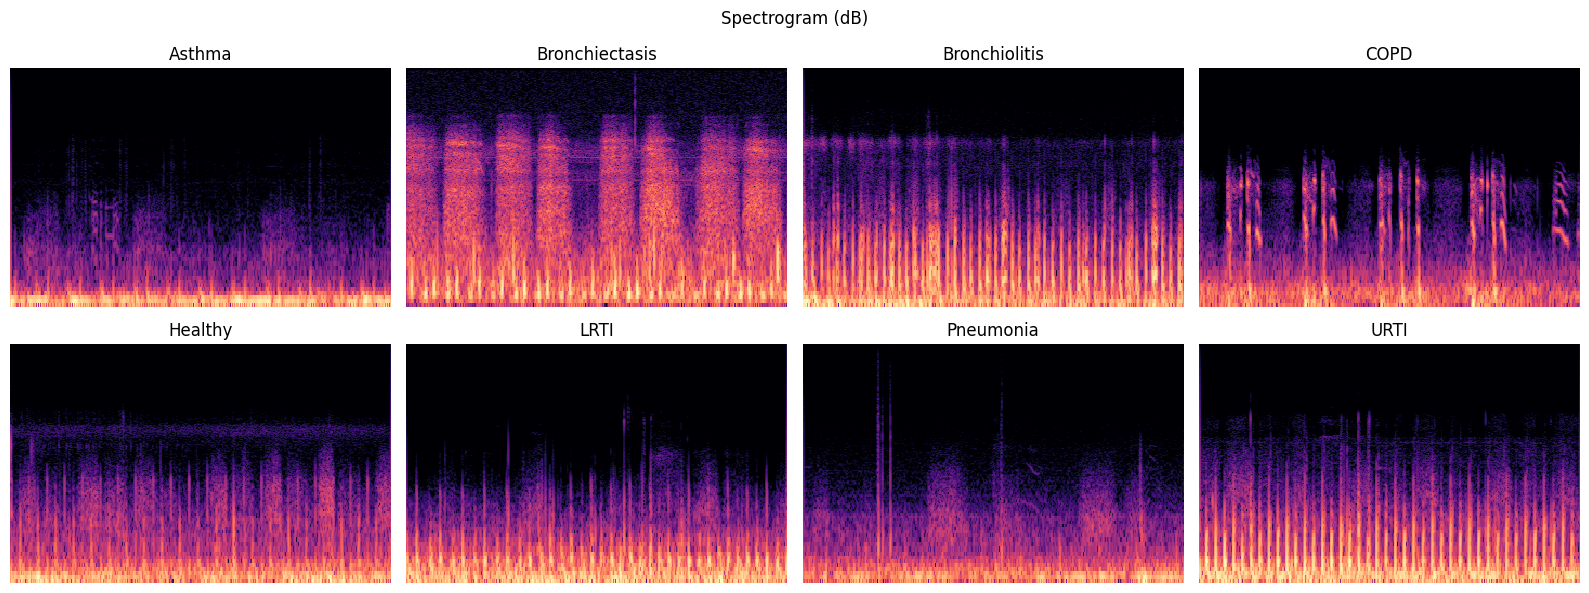

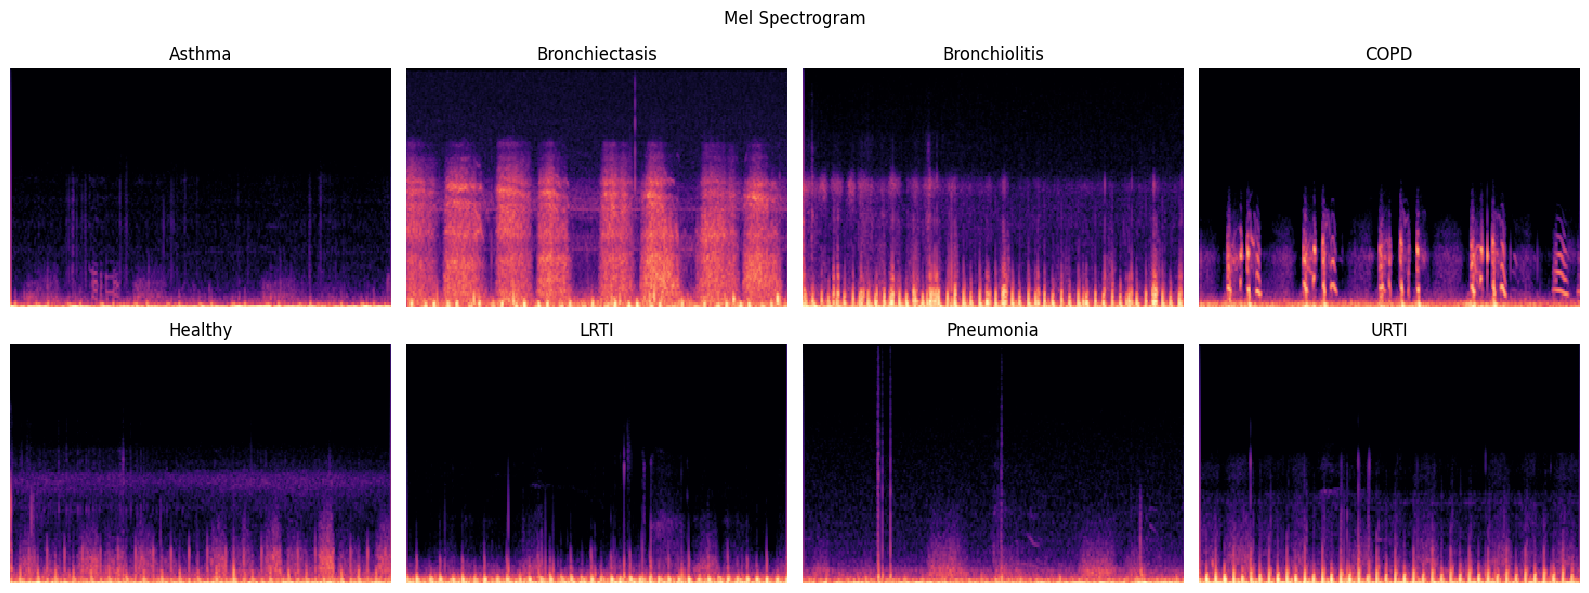

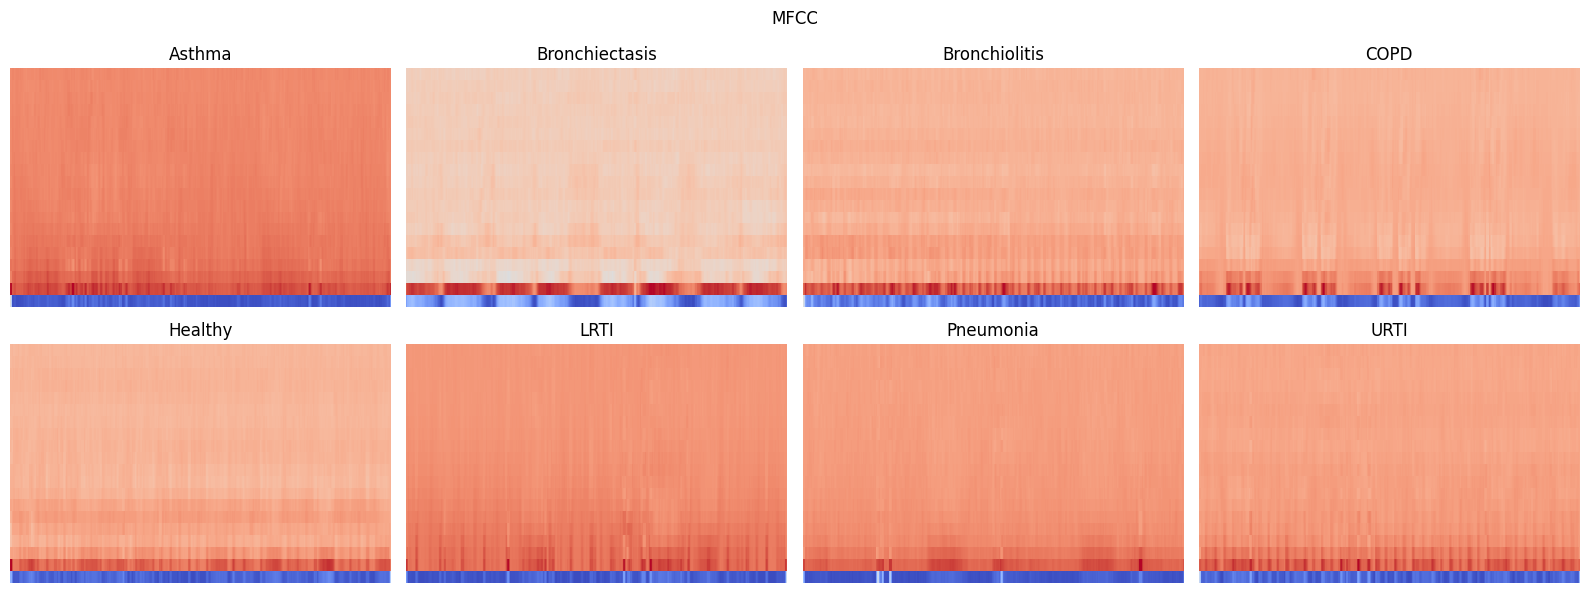

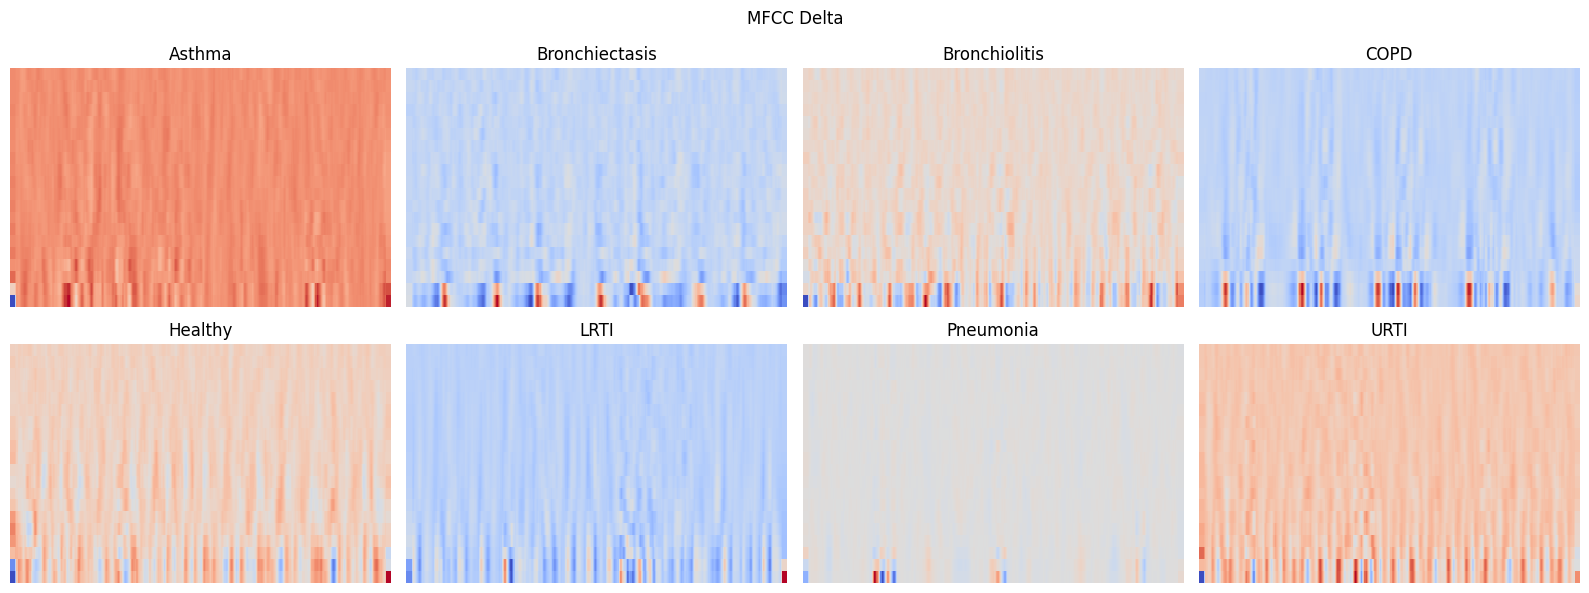

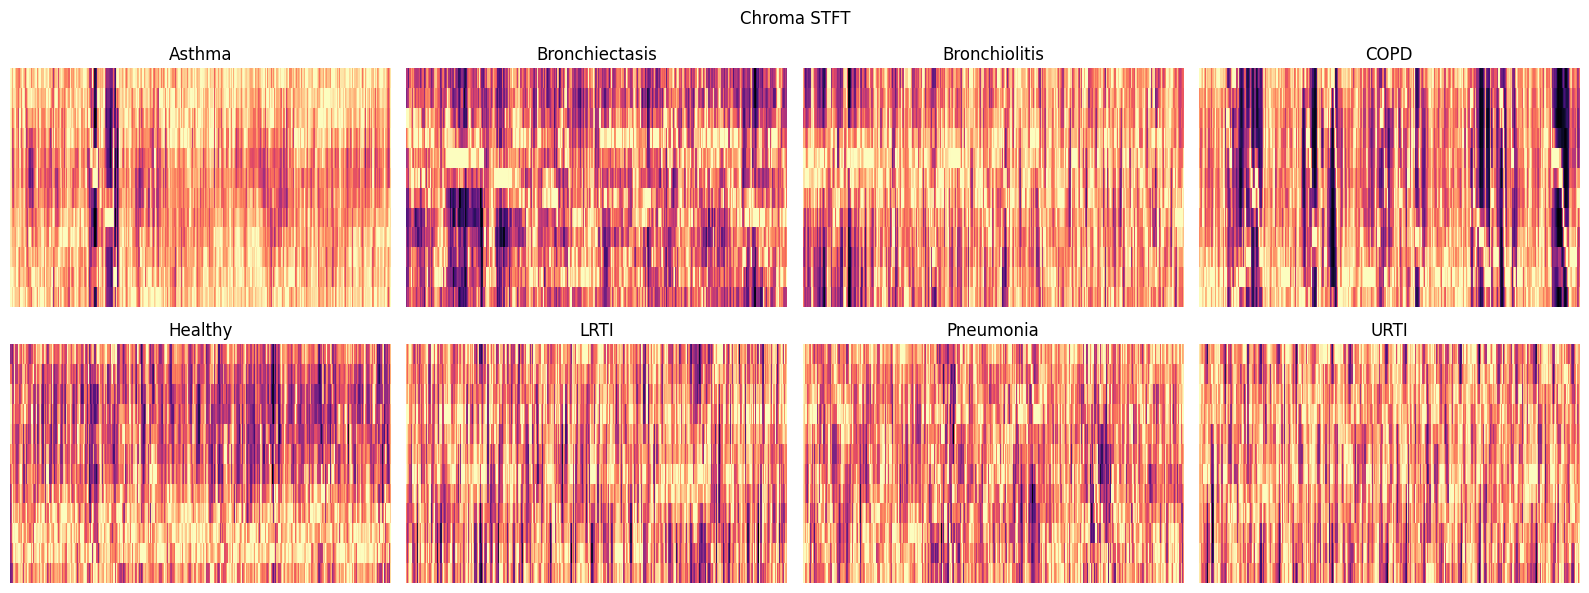

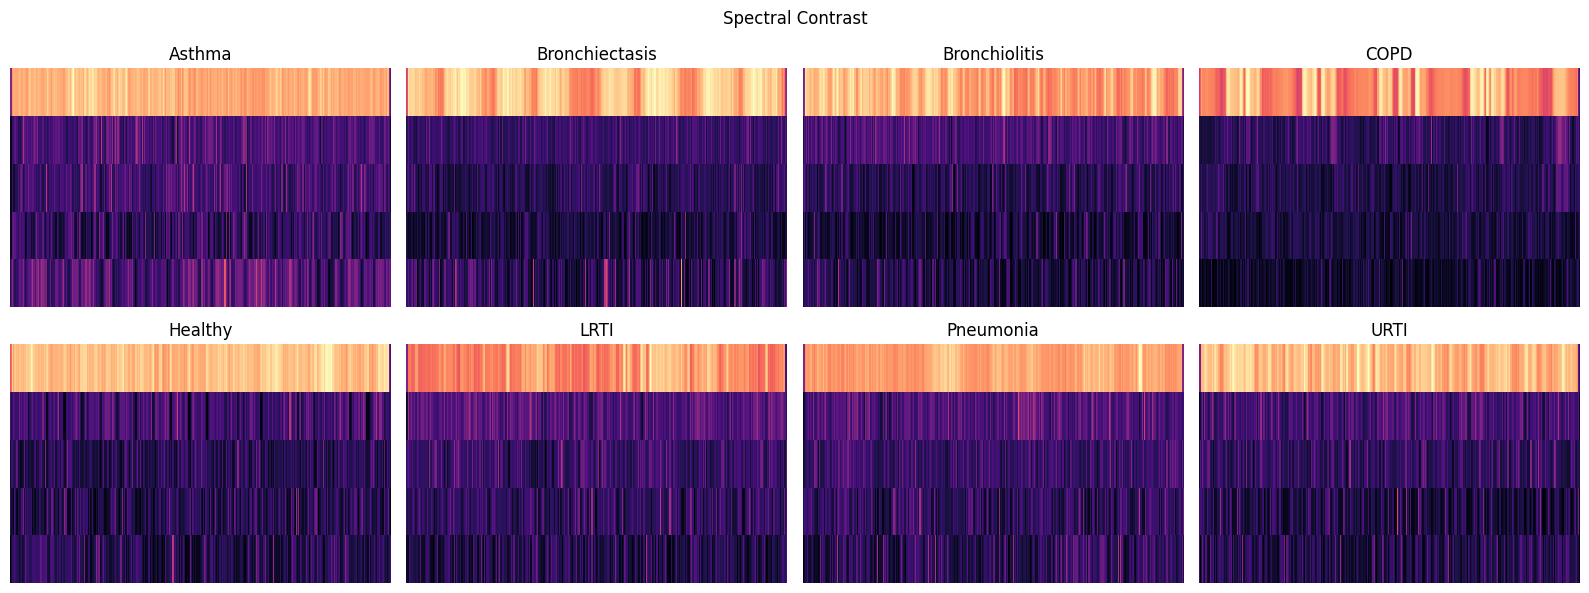

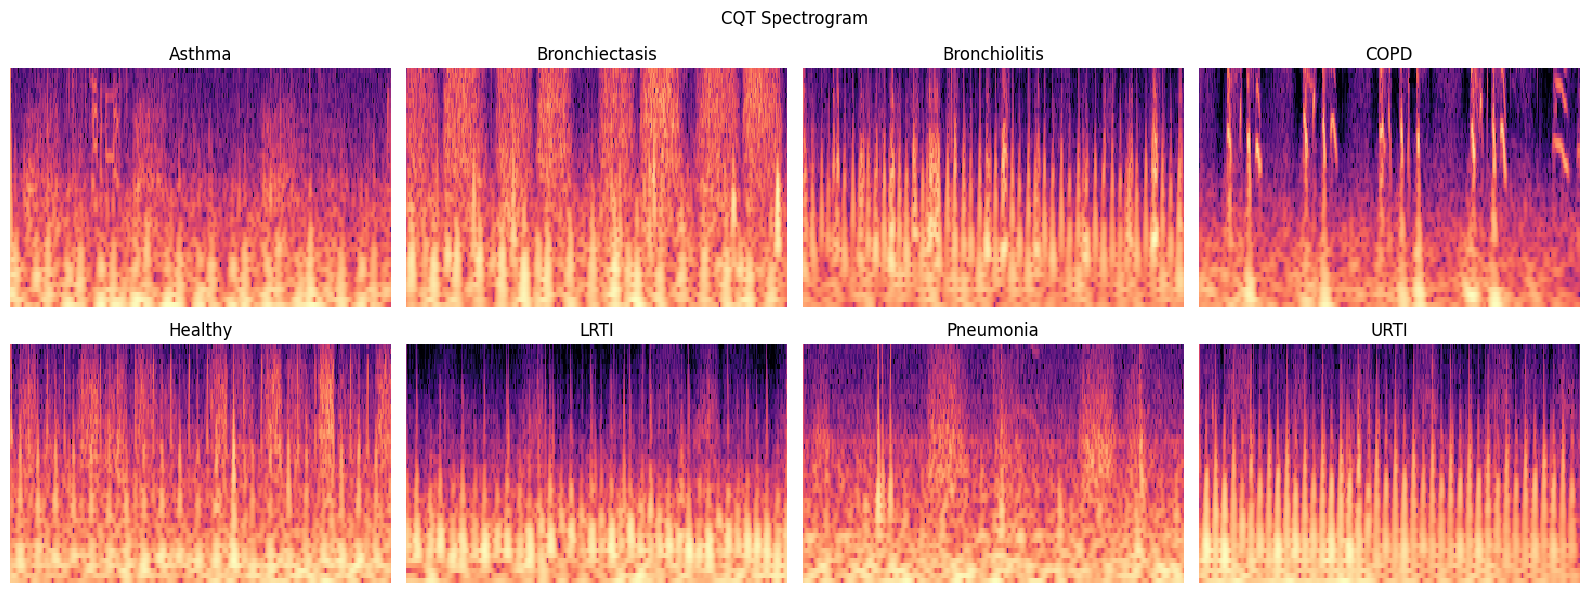

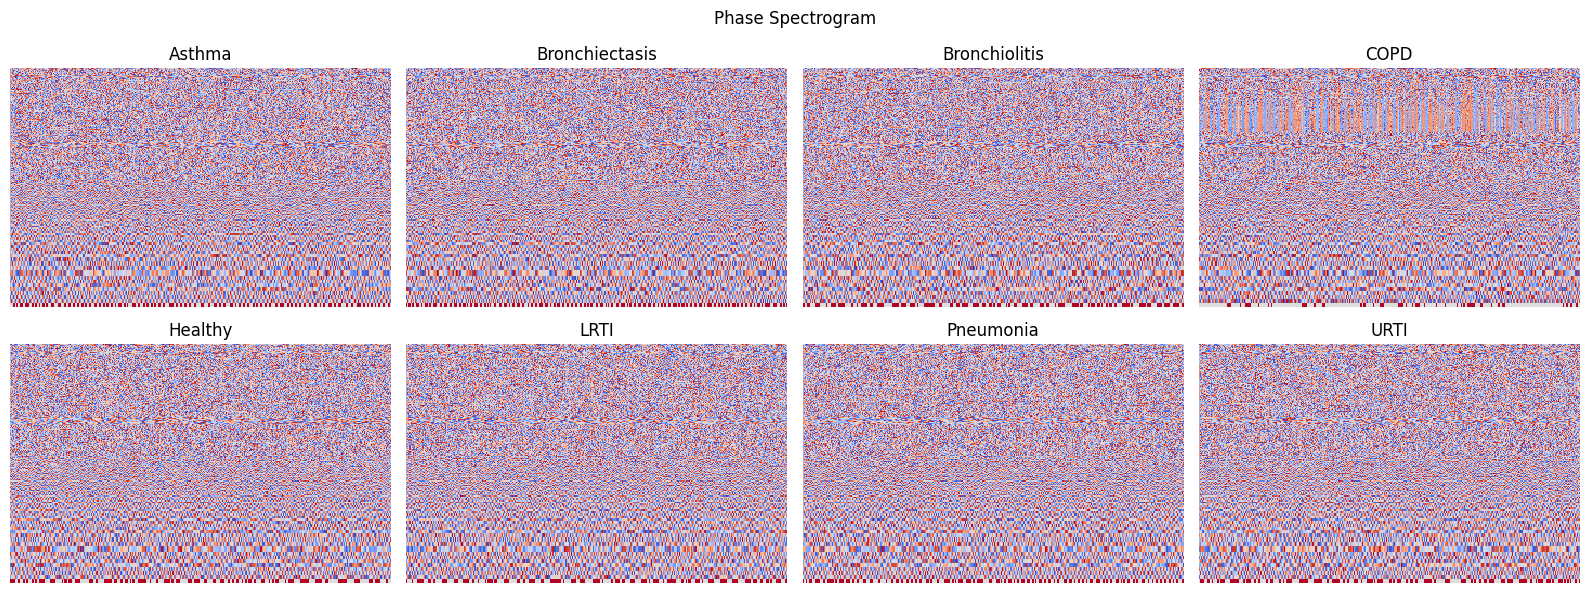

In [2]:
dataset = {
    "Asthma": "raw_data/Asthma/103_2b2_Ar_mc_LittC2SE.wav",
    "Bronchiectasis": "raw_data/Bronchiectasis/111_1b2_Tc_sc_Meditron.wav",
    "Bronchiolitis": "raw_data/Bronchiolitis/149_1b1_Al_sc_Meditron.wav",
    "COPD": "raw_data/COPD/104_1b1_Al_sc_Litt3200.wav",
    "Healthy": "raw_data/Healthy/102_1b1_Ar_sc_Meditron.wav",
    "LRTI": "raw_data/LRTI/108_1b1_Al_sc_Meditron.wav",
    "Pneumonia": "raw_data/Pneumonia/122_2b1_Al_mc_LittC2SE.wav",
    "URTI": "raw_data/URTI/101_1b1_Al_sc_Meditron.wav"
}

TARGET_SR = 18000
TARGET_DURATION = 10

def load_and_standardize(path):
    y, sr = librosa.load(path, sr=None)

    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)

    target_len = TARGET_SR * TARGET_DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    y = y / (np.max(np.abs(y)) + 1e-8)
    return y

signals = {label: load_and_standardize(path) for label, path in dataset.items()}
sr = TARGET_SR


def extract_features(y):
    stft = librosa.stft(y)
    mag = np.abs(stft)

    spec_db = librosa.amplitude_to_db(mag, ref=np.max)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc_delta = librosa.feature.delta(mfcc)

    chroma = librosa.feature.chroma_stft(S=mag, sr=sr)
    contrast = librosa.feature.spectral_contrast(
        S=mag,
        sr=sr,
        fmin=50,      # mais adequado para pulmão
        n_bands=4     # evita ultrapassar Nyquist
    )

    cqt = librosa.cqt(
        y,
        sr=sr,
        fmin=30,              # começa em baixa frequência (pulmão)
        n_bins=48,            # reduz alcance total
        bins_per_octave=12
    )

    cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

    phase = np.angle(stft)

    return {
        "spec_db": spec_db,
        "mel_db": mel_db,
        "mfcc": mfcc,
        "mfcc_delta": mfcc_delta,
        "chroma": chroma,
        "contrast": contrast,
        "cqt_db": cqt_db,
        "phase": phase
    }

features = {label: extract_features(y) for label, y in signals.items()}


def plot_grid(feature_key, title, y_axis='log', cmap='viridis'):
    plt.figure(figsize=(16, 6))

    for i, (label, feat_dict) in enumerate(features.items()):
        plt.subplot(2, 4, i+1)
        librosa.display.specshow(
            feat_dict[feature_key],
            sr=sr,
            x_axis='time',
            y_axis=y_axis,
            # cmap=cmap
        )
        plt.title(label)
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_grid("spec_db", "Spectrogram (dB)")
plot_grid("mel_db", "Mel Spectrogram", y_axis='mel')
plot_grid("mfcc", "MFCC", y_axis=None)
plot_grid("mfcc_delta", "MFCC Delta", y_axis=None)

plot_grid("chroma", "Chroma STFT", y_axis='chroma')
plot_grid("contrast", "Spectral Contrast", y_axis=None)

plot_grid("cqt_db", "CQT Spectrogram", y_axis='cqt_note')

plot_grid("phase", "Phase Spectrogram", cmap='twilight')
